In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_excel('../datasets/E Commerce Dataset.xlsx', sheet_name='E Comm')
df.head()

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


In [3]:
df = df.drop('CustomerID', axis=1)

## Data Preprocessing
- 모든 결측치 비율이 6% 미만이므로, Median Imputation from SimpleImputer.
- StandardScaler for Scaling the data and Median Imputation from SimpleImpute

In [4]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from imblearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as imbPipeline


def prepare_data(df):
    df_X = df.drop(columns=["Churn"])
    num_columns = df_X.select_dtypes(["int64", "float64"]).columns
    pipline_num = Pipeline(steps=[('imputer', SimpleImputer(strategy="median")), ('scaler', StandardScaler())])

    return num_columns, pipline_num

num_columns, pipline_num = prepare_data(df)

In [5]:
cat_columns = df.select_dtypes("object").columns
pipline_cat = Pipeline(steps=[('encoding', OneHotEncoder())])

transformer = ColumnTransformer(
    transformers=[('categorical_col', pipline_cat, cat_columns),
                  ('numerical_col', pipline_num, num_columns)]
    )

C:\Users\sunny\AppData\Local\Temp\ipykernel_14656\383005090.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_columns = df.select_dtypes("object").columns


### MODELING
- 데이터 불균형 문제를 해결하기 위해, 모델에서 가중치를 주고(비용 민감 학습), 데이터는 언더샘플링으로 조정

## Logistic Regression (base model)
- Train / Validation / Test를 나눠서
- Validation → 모델 튜닝용  (가장 좋은 모델을 찾기 위해)
- Test → 최종 평가용 (절대 건드리면 안 됨)

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

Y = df["Churn"]
X = df.drop(columns=["Churn"])
TEST_SIZE = 0.15
VAL_SIZE = 0.15
RANDOM_STATE = 42
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=Y)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=VAL_SIZE, random_state=RANDOM_STATE, stratify=y_train)

In [7]:
# 데이터 불균형을 해결하기 위해, 클래스 가중치 + TomekLinks 언더샘플링을 함께 사용해 로지스틱 회귀를 구현
# TomeLinks : 클래스 경계에 있는 애매한 데이터(노이즈)를 제거해서 → 데이터 품질을 개선하는 언더샘플링 기법
from sklearn.utils.class_weight import compute_class_weight
from sklearn.linear_model import LogisticRegression
from imblearn.under_sampling import TomekLinks

class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight = {0: class_weights[0], 1: class_weights[1]}
lg_model = LogisticRegression(max_iter=10_000, random_state=RANDOM_STATE, class_weight=class_weight)
undersampler = TomekLinks(sampling_strategy='majority')

pipeline = Pipeline([
          ('transformer', transformer),
          ('undersampler', undersampler),
          ('classifier', lg_model)
      ])

In [8]:
# model training
pipeline.fit(X_train, y_train)

,steps,"[('transformer', ...), ('undersampler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical_col', ...), ('numerical_col', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a stri

Accuracy on Validation Set: 81.058%
Accuracy on Train Set: 81.116%
              precision    recall  f1-score   support

           0       0.96      0.80      0.88       597
           1       0.47      0.85      0.60       121

    accuracy                           0.81       718
   macro avg       0.71      0.83      0.74       718
weighted avg       0.88      0.81      0.83       718

______________________________________________
PR AUC: 0.7204
ROC AUC: 0.9013


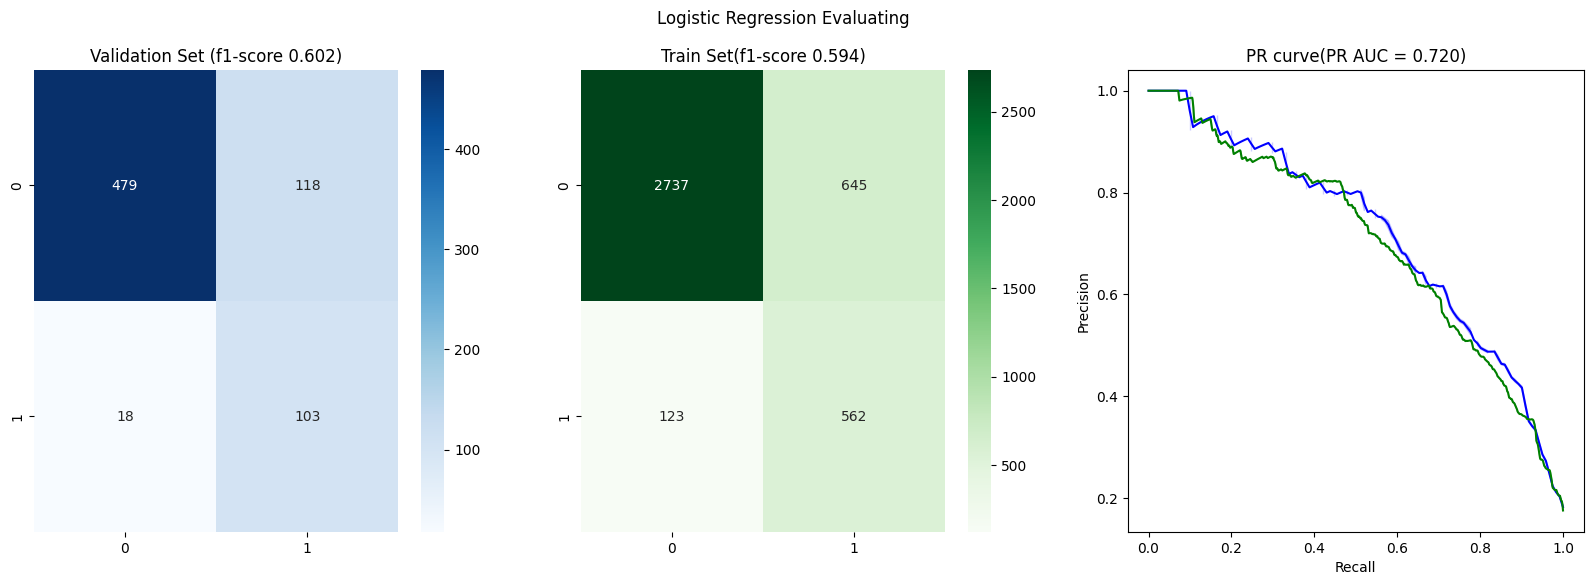

In [ ]:
# 모델 평가
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, confusion_matrix, classification_report, accuracy_score, precision_recall_curve, f1_score, recall_score, roc_auc_score, average_precision_score
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import seaborn as sns
import seaborn.objects as so
from IPython.display import Image

collect_results = []

def model_evaluation(pipeline, X_test, y_test, X_train, y_train, model, probability=True, test=False):
    if test:
        name = 'Test Set'
    else:
        name = 'Validation Set'
    # calculate accuracy
    y_train_pred = pipeline.predict(X_train)
    y_test_pred = pipeline.predict(X_test)
    accuracy = accuracy_score(y_test, y_test_pred)
    print(f"Accuracy on {name}: {accuracy * 100:0.5}%")
    print(f"Accuracy on Train Set: {accuracy_score(y_train, y_train_pred)* 100:0.5}%")
    report = classification_report(y_test, y_test_pred,output_dict=True)
    print(classification_report(y_test, y_test_pred))
    f1_test = report['1']['f1-score']
    recall_test_val = report['1']['recall']

    print('______________________________________________')
    #confusion matrixes
    fig, ax =plt.subplots(1, 3, figsize=(20, 6))

    cm_lr_test = confusion_matrix(y_test, y_test_pred)
    ax[0].set_title(f'{name} (f1-score {f1_test:.3f})')
    sns.heatmap(cm_lr_test, annot = True,fmt = 'd', cmap ='Blues', ax=ax[0])

    f1_train = f1_score(y_train, y_train_pred)
    cm_lr = confusion_matrix(y_train, y_train_pred)
    ax[1].set_title(f'Train Set(f1-score {f1_train:.3f})')
    sns.heatmap(cm_lr,annot = True,fmt = 'd', cmap ='Greens', ax=ax[1])
    if probability:
        y_train_pred_proba = pipeline.predict_proba(X_train)[:, 1]
        y_test_pred_proba = pipeline.predict_proba(X_test)[:, 1]
    else:
        y_train_pred_proba = pipeline.predict(X_train)
        y_test_pred_proba = pipeline.predict(X_test)

    train_fpr, train_tpr, tr_thresholds = roc_curve(y_train, y_train_pred_proba)
    test_fpr, test_tpr, te_thresholds = roc_curve(y_test, y_test_pred_proba)

    # Calculate the PR AUC  : Precision-Recall Curve 아래 면적
    pr_auc = average_precision_score(y_test, y_test_pred_proba)
    print(f"PR AUC: {pr_auc:.4f}")

    # ROC AUC (for comparison)
    roc_auc = roc_auc_score(y_test, y_test_pred_proba)
    print(f"ROC AUC: {roc_auc:.4f}")

    # Precision-Recall curve
    precision_test, recall_test, _ = precision_recall_curve(y_test, y_test_pred_proba)
    precision_train, recall_train, _ = precision_recall_curve(y_train, y_train_pred_proba)
    ax[2].set_title(f'PR curve(PR AUC = {pr_auc:.3f})')
    sns.lineplot(x=recall_test, y=precision_test, color = 'blue',  ax=ax[2])
    sns.lineplot(x=recall_train, y=precision_train, color = 'green',  ax=ax[2])
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    fig.suptitle(f'{model} Evaluating')
    plt.savefig(f'../img/{model}.png')
    plt.show()

    return {
    'Accuracy Score': accuracy,
    'F1-score': f1_test,
    'Recall': recall_test_val,
    'PR AUC': pr_auc,
    'Model': model
    }
model = 'Logistic Regression'
collect_results.append(model_evaluation(pipeline, X_val, y_val,  X_train, y_train, model='Logistic Regression'))

### feature Engineering
- 주문당 캐시백 (Cashback per order)
→ 주문 1건당 평균 캐시백 금액을 계산
- 주문당 앱 사용 시간 (Average hour spend on app per order)
→ 한 주문당 사용자가 앱에서 소비한 평균 시간
- 불만 제기 후 만족도 (Satisfaction score after complain)
→ 불만을 제기한 사용자들에 대해서만 만족도 점수를 활용
- 월별 캐시백 금액 (Cashback amount per month)
→ 한 달 동안 평균적으로 받은 캐시백 금액
- 다항 피처 추가 (Polynomial features)
→ 가장 상관관계가 높은 변수들을 기반으로 다항식 형태의 새로운 변수 생성

In [11]:
def add_features_to_set(df):
    df_new_features = df.copy()
    df_new_features['cashback_per_order'] = df['CashbackAmount'] / df['OrderCount']
    df_new_features['avg_hour_spend_on_app_per_order'] = df['HourSpendOnApp'] / df['OrderCount']
    df_new_features['satisfaction_score_after_complain'] = df['Complain'] * df['SatisfactionScore']
    df_new_features['cashback_amount_per_month'] = df['CashbackAmount']/ (df['Tenure'] + 1)
    df_new_features['satisfaction_score_2'] = df['SatisfactionScore'] * df['Complain']
    df_new_features['tenure_2'] =  df['Tenure'] * df['Tenure']
    df_new_features['tenure_3'] =  df['Tenure'] * df['Tenure'] * df['Tenure']
    df_new_features['DaySinceLastOrder_2'] = df['DaySinceLastOrder'] * df['DaySinceLastOrder']
    df_new_features['cashback_amount_per_month_2'] = df_new_features['cashback_amount_per_month'] * df_new_features['cashback_amount_per_month']

    return df_new_features

X_train_2 = add_features_to_set(X_train)
X_val_2 = add_features_to_set(X_val)
X_test_2 = add_features_to_set(X_test)

In [12]:
len(X_train_2.columns)

27